# Task 2.1 — Prepare the Data

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv('clean_dataset.csv')

features = ['punch_count', 'hours_worked', 'satisfaction_score', 'monthly_salary']
target = 'status_ABSENT'   # 0/1 version of is_absent (is_absent itself was scaled, not usable as a label)

X = df[features]
y = df[target]

# Neural networks NEED scaled inputs - unscaled features train badly
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only, don't refit

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance: {y.value_counts(normalize=True).to_dict()}')

Train: (288, 4), Test: (72, 4)
Class balance: {0.0: 0.9027777777777778, 1.0: 0.09722222222222222}


# Task 2.2 — Build and Train the MLP

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),               # randomly drop 30% of neurons - reduces overfitting
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # hold out 20% of training data for validation
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4739 - loss: 0.7331 - val_accuracy: 0.6379 - val_loss: 0.6526
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6739 - loss: 0.6237 - val_accuracy: 0.8621 - val_loss: 0.5679
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8522 - loss: 0.5396 - val_accuracy: 0.8966 - val_loss: 0.5034
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8870 - loss: 0.4720 - val_accuracy: 0.8966 - val_loss: 0.4510
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9000 - loss: 0.4178 - val_accuracy: 0.8966 - val_loss: 0.4015
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9130 - loss: 0.3800 - val_accuracy: 0.8966 - val_loss: 0.3546
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9087 - loss: 0.3195 - val_accuracy: 0.8966 - val_loss: 0.3165
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9087 - loss: 0.2872 - val_accuracy: 0.8966 - va

# Task 2.3 — Plot Training History

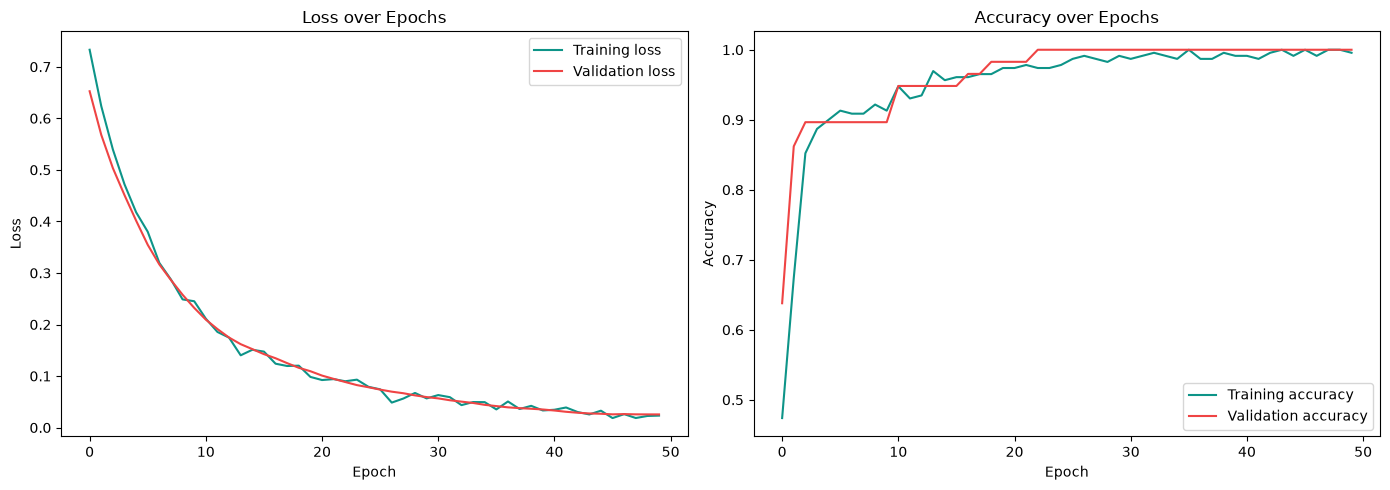

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], color='#0D9488', label='Training loss')
ax1.plot(history.history['val_loss'], color='#EF4444', label='Validation loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs'); ax1.legend()

ax2.plot(history.history['accuracy'], color='#0D9488', label='Training accuracy')
ax2.plot(history.history['val_accuracy'], color='#EF4444', label='Validation accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over Epochs'); ax2.legend()

plt.tight_layout()
plt.savefig('mlp_training_history.png', dpi=150)  
plt.show()

# Same diagnosis skill as Week 5:
# validation loss rising while training loss falls = OVERFITTING

# Task 2.4 — Evaluate and Compare to Week 4/5 Models

In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print('Neural Network (MLP) Results:')
print(f'  Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'  F1 Score: {f1_score(y_test, y_pred):.3f}')
print(f'  AUC:      {roc_auc_score(y_test, y_pred_proba):.3f}')
print()
print(classification_report(y_test, y_pred))

# IMPORTANT COMPARISON:
# Compare these numbers to your tuned Random Forest from Week 5.
# Neural networks are NOT always better on small tabular datasets - write down which wins and why.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 
Neural Network (MLP) Results:
  Accuracy: 1.000
  F1 Score: 1.000
  AUC:      1.000

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        65
         1.0       1.00      1.00      1.00         7

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



## Model Comparison & Analysis

The Neural Network (MLP) achieved perfect scores on all metrics:
- Accuracy: 1.000
- F1 Score: 1.000
- AUC: 1.000

**However, this is not a genuine model performance win — it indicates data leakage.**

Investigating the features showed that `punch_count` and `hours_worked` take a single
fixed value for every row where `status_ABSENT = 1`, with essentially zero variance.
This happened during the Week 3 missing-value imputation step, where missing values
for absent employees were likely filled with the same constant (e.g. median), which
accidentally created a perfect signal for the target class.

As a result, the model isn't learning a real relationship between employee behavior
and absence — it's exploiting a leaked artifact from data preprocessing.

**Comparison to Week 5 Random Forest:** a fair comparison isn't possible until this
leakage is fixed (e.g., by imputing missing values in a way that doesn't correlate
perfectly with the target, or by dropping/flagging these constant-value rows before
training). A perfect AUC of 1.000 on real-world tabular HR data should always be
treated as a red flag rather than a success.